In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\Baciucu\AC2026\SI\ml_project\sklearn_env\nlp_dataset


In [3]:
import pandas as pd

dataset_path = PROJECT_ROOT / "data" / "final" / "medical_dataset.csv"

df = pd.read_csv(dataset_path)
df.head()

,symptom,disease,treatment_recommendation,source_name,source_url,source_topic,confidence,evidence,model_used,extraction_status,validation_status,validation_notes
0,fever,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,The page links fever with influenza symptoms a...,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.
1,cough,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,The page links cough with influenza symptoms a...,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.
2,headache,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,The page links headache with influenza symptom...,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.
3,fatigue (tiredness),influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,The page links fatigue with influenza symptoms...,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.
4,vomiting,influenza,"Rest, drink fluids, and seek medical care if s...",MedlinePlus,https://medlineplus.gov/flu.html,flu,0.85,The page mentions vomiting as a symptom of inf...,ollama/llama3.2:3b,extracted,valid,Passed rule-based validation.


In [3]:
len(df)

72

In [4]:
df["validation_status"].value_counts()

validation_status
valid           67
needs_review     5
Name: count, dtype: int64

In [5]:
df["source_name"].value_counts()

source_name
MedlinePlus    41
NHS            31
Name: count, dtype: int64

In [6]:
df["disease"].value_counts().head(10)

disease
influenza                  13
migraine                    9
iron deficiency anaemia     8
diabetes                    7
pneumonia                   7
high blood pressure         6
common cold                 4
asthma                      4
dehydration                 4
chronic bronchitis          3
Name: count, dtype: int64

In [7]:
df["symptom"].value_counts().head(10)

symptom
shortness of breath    7
fever                  5
cough                  4
chest pain             4
headache               3
diarrhea               2
coughing               2
headaches              2
fatigue (tiredness)    1
vomiting               1
Name: count, dtype: int64

In [8]:
df.isna().sum()

symptom                     0
disease                     0
treatment_recommendation    0
source_name                 0
source_url                  0
source_topic                0
confidence                  0
evidence                    0
model_used                  0
extraction_status           0
validation_status           0
validation_notes            0
dtype: int64

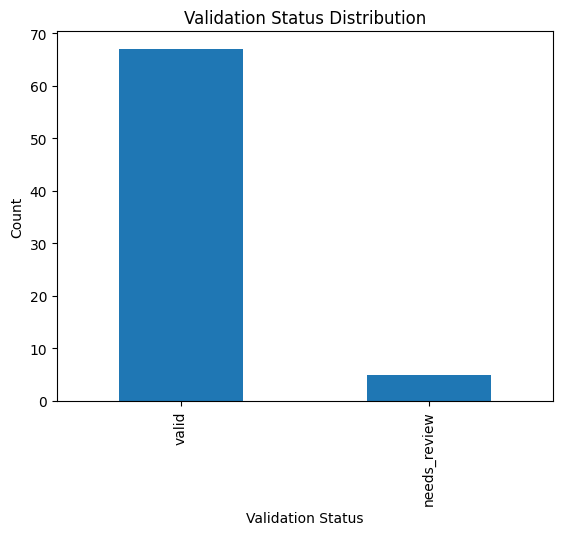

In [4]:
import matplotlib.pyplot as plt

df["validation_status"].value_counts().plot(kind="bar")
plt.title("Validation Status Distribution")
plt.xlabel("Validation Status")
plt.ylabel("Count")
plt.show()

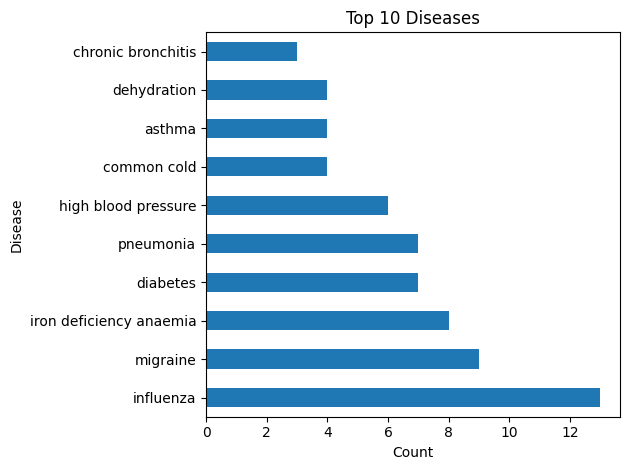

In [5]:
df["disease"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Diseases")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig("../reports/top_10_diseases.png")
plt.show()

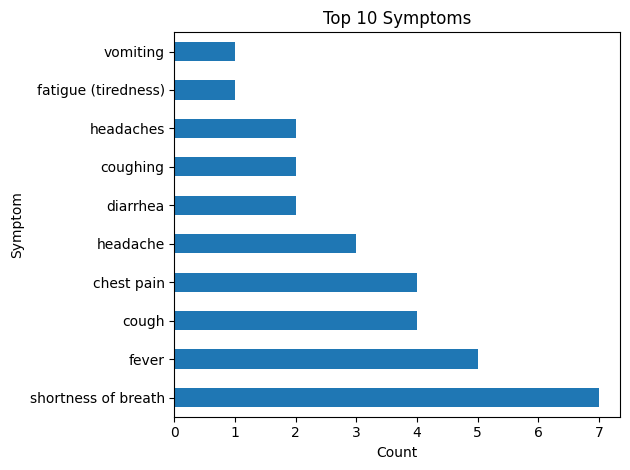

In [6]:
df["symptom"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Symptoms")
plt.xlabel("Count")
plt.ylabel("Symptom")
plt.tight_layout()
plt.savefig("../reports/top_10_symptoms.png")
plt.show()

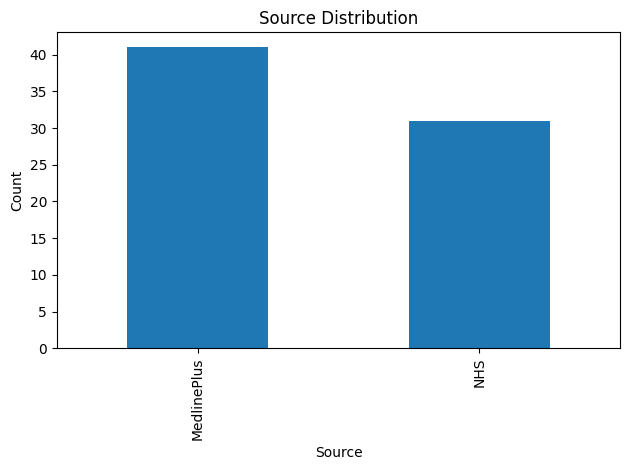

In [7]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/source_distribution.png")
plt.show()

In [10]:
df[df["confidence"] < 0.8][
    ["symptom", "disease", "confidence", "validation_status"]
]

,symptom,disease,confidence,validation_status
21,shortness of breath,high blood pressure,0.70,needs_review
37,dizziness,anemia,0.75,valid
45,loss of taste and smell,common cold,0.75,needs_review
56,stiff neck,migraine,0.70,valid
57,peeing more,migraine,0.70,valid
61,shortness of breath,bronchitis,0.70,valid


In [11]:
df[df["validation_status"] == "needs_review"][
    ["symptom", "disease", "treatment_recommendation", "validation_notes"]
]

,symptom,disease,treatment_recommendation,validation_notes
8,coughing,common cold,"Rest, drink fluids, and seek medical care if s...",Treatment contains dosage instructions.
20,chest pain,high blood pressure,"If you have high blood pressure, your doctor m...",risky treatment wording: prescribe
21,shortness of breath,high blood pressure,"If you have high blood pressure, your doctor m...",risky treatment wording: prescribe
45,loss of taste and smell,common cold,"There is no cure for the common cold, but symp...",risky treatment wording: cure
58,chest pain,pneumonia,You'll usually be given antibiotics to treat p...,risky treatment wording: antibiotic


In [12]:
summary = {
    "total_rows": len(df),
    "unique_symptoms": df["symptom"].nunique(),
    "unique_diseases": df["disease"].nunique(),
    "unique_sources": df["source_name"].nunique(),
    "average_confidence": round(df["confidence"].mean(), 3),
    "valid_rows": int((df["validation_status"] == "valid").sum()),
    "needs_review_rows": int((df["validation_status"] == "needs_review").sum()),
    "rejected_rows": int((df["validation_status"] == "rejected").sum()),
}

summary

{'total_rows': 72,
 'unique_symptoms': 51,
 'unique_diseases': 13,
 'unique_sources': 2,
 'average_confidence': np.float64(0.853),
 'valid_rows': 67,
 'needs_review_rows': 5,
 'rejected_rows': 0}